# 实验一：线性回归实验

- 参考课程仓库： [MachineLearning_Student](https://github.com/hong-hong3/MachineLearning_Student)
- 原版需要手动下载 `linear_regression.tgz` 并上传解压才能跑；这里把用到的数据直接内嵌在代码里，点开就能在 Colab 里从头跑到尾


## 实验目标

- 理解一元线性回归的基本思想和闭式解
- 用 sklearn 和手写 numpy 两种方式实现，验证结果一致
- 在真实的房价数据上完成训练、预测、评估


## 数学原理

一元线性回归假设 $y = ax + b$，目标是让预测值和真实值的均方误差最小：

$$Q(a,b)=\sum_{i=1}^n (y_i - (ax_i+b))^2$$

对 $a,b$ 求偏导并令其为零，可以解出闭式解：

$$a = \frac{\text{cov}(x,y)}{\text{var}(x)}, \qquad b = \bar y - a\bar x$$

下面先在一组模拟数据上验证「sklearn 拟合」和「按上面公式手写 numpy 计算」两种方式结果一致，再把同样的流程应用到真实房价数据上。


In [ ]:
import numpy as np
import pandas as pd
# 从 sklearn 的评估指标模块中导入三个回归评估指标：
# - mean_squared_error：均方误差 (MSE)，衡量预测值与真实值差的平方的平均
# - mean_absolute_error：平均绝对误差 (MAE)，衡量预测值与真实值差的绝对值的平均
# - r2_score：决定系数 R²，衡量模型对数据的拟合优度（越接近1越好）
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False


## 第一部分：sklearn 与手写 numpy 一致性验证

用 $y=2x+1$ 加一点噪声构造模拟数据，分别用 sklearn 和 numpy 公式算斜率、截距，对比结果。


In [ ]:
# 监督学习里的线性回归
# 模拟数据：真实关系 y = 2x + 1，加了一点噪声
x_demo = [1, 2, 3, 4, 5]
y_demo = [3.1, 5.2, 6.8, 8.8, 11.1]
# 定义因变量 y 的取值列表（带噪声的观测值），理论上 y = 2x + 1 应得到：[3, 5, 7, 9, 11]

X_demo = np.array(x_demo).reshape(-1, 1)
# 将 x 列表转为 NumPy 数组，并 reshape 成二维形状 (5, 1)
y_demo_arr = np.array(y_demo)

model_demo = LinearRegression()
# 实例化一个线性回归模型对象
# 此时模型还未训练，只是一个“空壳”，参数（斜率、截距）都是未定的
model_demo.fit(X_demo, y_demo_arr)#fit():用数据训练，模型才真正学到东西
# 内部会通过最小二乘法寻找一条直线，使得预测值与真实值的误差平方和最小
# 训练完成后，模型的斜率和截距会被保存在对象的属性中

print("sklearn 斜率:", model_demo.coef_[0])
print("sklearn 截距:", model_demo.intercept_)
print("x=6 时预测 y:", model_demo.predict([[6]])[0])#.predict()：用学到的知识做预测


sklearn 斜率: 1.96
sklearn 截距: 1.12
x=6 时预测 y: 12.879999999999999


In [ ]:
# 手写 numpy 版本，对照上面的公式 a = cov(x,y)/var(x), b = mean(y) - a*mean(x)
var_x = np.var(x_demo, ddof=1)
cov_xy = np.cov(x_demo, y_demo)[0][1]
a_np = cov_xy / var_x
b_np = np.mean(y_demo) - a_np * np.mean(x_demo)

print("numpy 斜率:", a_np)
print("numpy 截距:", b_np)
print("两种方式是否一致:", np.isclose(a_np, model_demo.coef_[0]) and np.isclose(b_np, model_demo.intercept_))


numpy 斜率: 1.9600000000000002
numpy 截距: 1.1199999999999992
两种方式是否一致: True


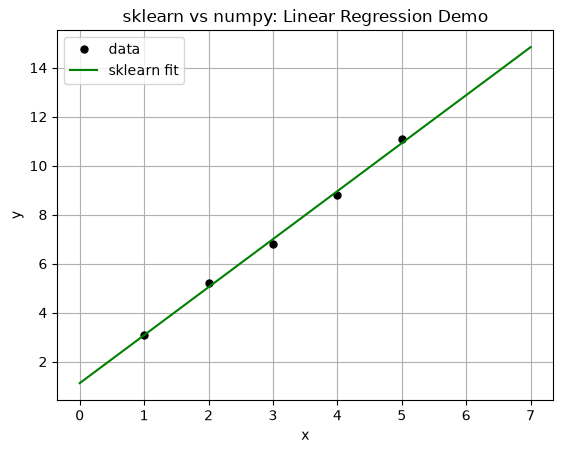

In [ ]:
plt.figure()
plt.title("sklearn vs numpy: Linear Regression Demo")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.plot(x_demo, y_demo, "k.", markersize=10, label="data")
x_line = np.linspace(0, 7, 50).reshape(-1, 1)
plt.plot(x_line, model_demo.predict(x_line), "g-", label="sklearn fit")
plt.legend()
plt.show()


## 第二部分：房价预测实战

数据来自原实验的 `price_info.csv`（7 条样本：`square_feet` 房屋面积 → `price` 房价），直接内嵌在代码里，不需要下载/上传。


In [ ]:
# 数据来自 linear_regression.tgz 里的 price_info.csv，内嵌避免手动上传解压
price_data = {
    "square_feet": [150, 200, 250, 300, 350, 400, 600],
    "price":       [6450, 7450, 8450, 9450, 11450, 15450, 18450],
}

def get_data():
    """构造房价数据，返回 X（二维，square_feet）和 y（一维，price）"""
    df = pd.DataFrame(price_data)
    X = df[["square_feet"]].values
    y = df["price"].values
    return X, y

X, y = get_data()
print(pd.DataFrame(price_data))


   square_feet  price
0          150   6450
1          200   7450
2          250   8450
3          300   9450
4          350  11450
5          400  15450
6          600  18450


In [ ]:
def get_linear_model(X, y):
    """用 sklearn 训练线性回归模型"""
    model = LinearRegression()
    model.fit(X, y)
    return model

model = get_linear_model(X, y)
print("斜率(每平方英尺涨价):", model.coef_[0])
print("截距:", model.intercept_)


斜率(每平方英尺涨价): 28.776595744680854
截距: 1771.808510638295


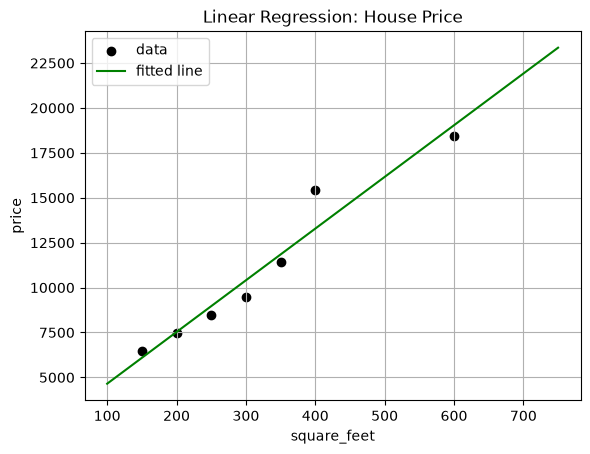

In [ ]:
def show_linear_line(X, y, model, title="Linear Regression: House Price"):
    """画散点图 + 拟合直线"""
    plt.figure()
    plt.title(title)
    plt.xlabel("square_feet")
    plt.ylabel("price")
    plt.grid(True)
    plt.scatter(X, y, color="black", label="data")
    x_line = np.linspace(X.min() - 50, max(X.max(), 700) + 50, 100).reshape(-1, 1)
    plt.plot(x_line, model.predict(x_line), "g-", label="fitted line")
    plt.legend()
    plt.show()

show_linear_line(X, y, model)


In [ ]:
# 700平方英尺时的预测房价
pred_700 = model.predict([[700]])[0]
print(f"700 平方英尺时的预测价格: {pred_700:.2f}")


700 平方英尺时的预测价格: 21915.43


### 模型评估

样本只有 7 条，不做严格的训练/测试集切分（切了测试集也没几个点，没有统计意义），
这里报告的是**训练集拟合优度**：模型在已见过的 7 个点上预测得有多准，用来说明"这条直线有多贴合数据"，
不是在衡量对未见过数据的泛化能力。


In [ ]:
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"MSE (均方误差): {mse:.2f}")
print(f"MAE (平均绝对误差): {mae:.2f}")
print(f"R2  (决定系数): {r2:.4f}")


MSE (均方误差): 930471.12
MAE (平均绝对误差): 722.64
R2  (决定系数): 0.9447


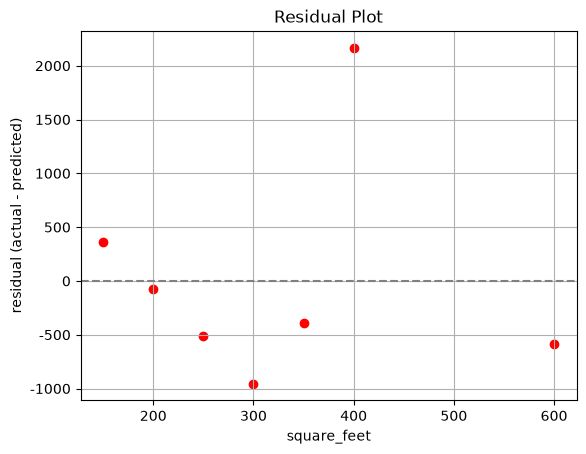

残差: [ 361.70212766  -77.12765957 -515.95744681 -954.78723404 -393.61702128
 2167.55319149 -587.76595745]


In [ ]:
# 残差图：预测值 - 真实值，理想情况下应该随机散布在 0 附近，没有明显规律
residuals = y - y_pred

plt.figure()
plt.title("Residual Plot")
plt.xlabel("square_feet")
plt.ylabel("residual (actual - predicted)")
plt.axhline(0, color="gray", linestyle="--")
plt.scatter(X, residuals, color="red")
plt.grid(True)
plt.show()

print("残差:", residuals)


## 结果小结

- 斜率 ≈ 28.78：每多 1 平方英尺，房价大约上涨 28.78
- 截距 ≈ 1771.81：理论上面积为 0 时的基准价格（无实际意义，只是直线参数）
- 700 平方英尺预测价格 ≈ 21915.43
- R² ≈ 0.945：这条直线解释了约 94.5% 的房价波动，拟合较好
- 残差图上看，600 平方英尺那个点残差最大——样本量太小（只有7条），这一个点对直线的拉动效应很明显，是这个数据集本身的局限，不是模型的问题

报告里可以围绕这几点写:模型学到了什么关系、拟合效果怎么样(用R²和残差图佐证)、有什么局限(样本量小、600平方英尺那个点的杠杆效应)。
